Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Mapping Predicted Probabilities of Wind Farm Presence
Predictions generated for 8,518 tracts


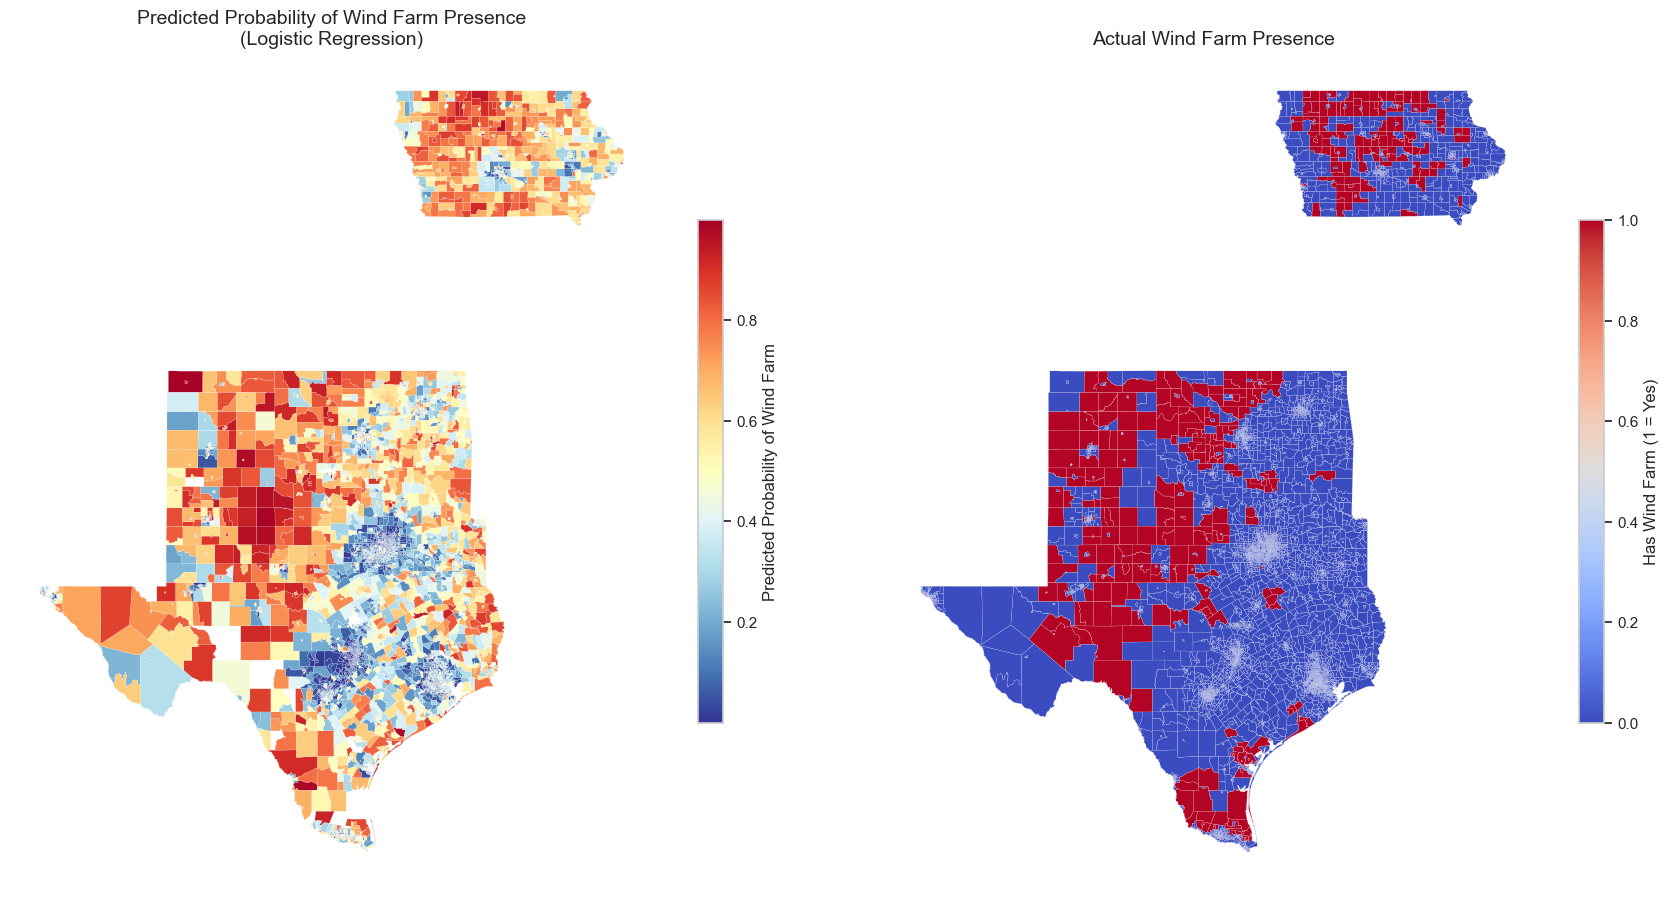


Predictions saved to: data/processed/tracts_with_predictions.parquet


In [1]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib  # Optional: for saving/loading the model later

sns.set_theme(style="whitegrid")

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Mapping Predicted Probabilities of Wind Farm Presence")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + RE-CREATE FEATURES (same as modeling)
# ============================================================

gdf = gpd.read_parquet(file_path)

# Re-create engineered features
gdf["pct_recent_housing"] = gdf["housing_built_2010_or_later"] / (gdf["total_housing_units"] + 1)
gdf["housing_density"] = gdf["total_housing_units"] / (gdf["total_population"] + 1)
gdf["income_vs_home_value"] = gdf["median_household_income"] / (gdf["median_home_value"] + 1)

feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "pct_recent_housing",
    "housing_density",
    "income_vs_home_value"
]

# ============================================================
# 2. PREPARE DATA FOR PREDICTION
# ============================================================

df_model = gdf[feature_cols + ["has_wind_farm"]].dropna().copy()
X = df_model[feature_cols]

# Scale features (use same scaler as training)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 3. TRAIN MODEL (or load saved model)
# ============================================================

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_scaled, df_model["has_wind_farm"])

# Generate predicted probabilities
df_model["predicted_prob"] = model.predict_proba(X_scaled)[:, 1]

# Merge predictions back to full GeoDataFrame
gdf = gdf.merge(
    df_model[["predicted_prob"]], 
    left_index=True, 
    right_index=True, 
    how="left"
)

print(f"Predictions generated for {df_model.shape[0]:,} tracts")

# ============================================================
# 4. CREATE CHOROPLETH MAPS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

# Map 1: Predicted Probability
gdf.plot(
    column="predicted_prob",
    cmap="RdYlBu_r",
    linewidth=0.1,
    edgecolor="white",
    ax=axes[0],
    legend=True,
    legend_kwds={"label": "Predicted Probability of Wind Farm", "shrink": 0.6}
)
axes[0].set_title("Predicted Probability of Wind Farm Presence\n(Logistic Regression)", fontsize=14)
axes[0].axis("off")

# Map 2: Actual Wind Farm Presence
gdf.plot(
    column="has_wind_farm",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="white",
    ax=axes[1],
    legend=True,
    legend_kwds={"label": "Has Wind Farm (1 = Yes)", "shrink": 0.6}
)
axes[1].set_title("Actual Wind Farm Presence", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

# ============================================================
# 5. SAVE PREDICTIONS (Optional but recommended)
# ============================================================

output_path = "data/processed/tracts_with_predictions.parquet"
gdf.to_parquet(output_path, index=False)
print(f"\nPredictions saved to: {output_path}")

print("=" * 70)

Working directory set to: /Users/jakemammen/Library/CloudStorage/OneDrive-Personal/Desktop/windfarm_socioecon_geospatial_analysis
Mapping Predicted Probabilities + Residuals


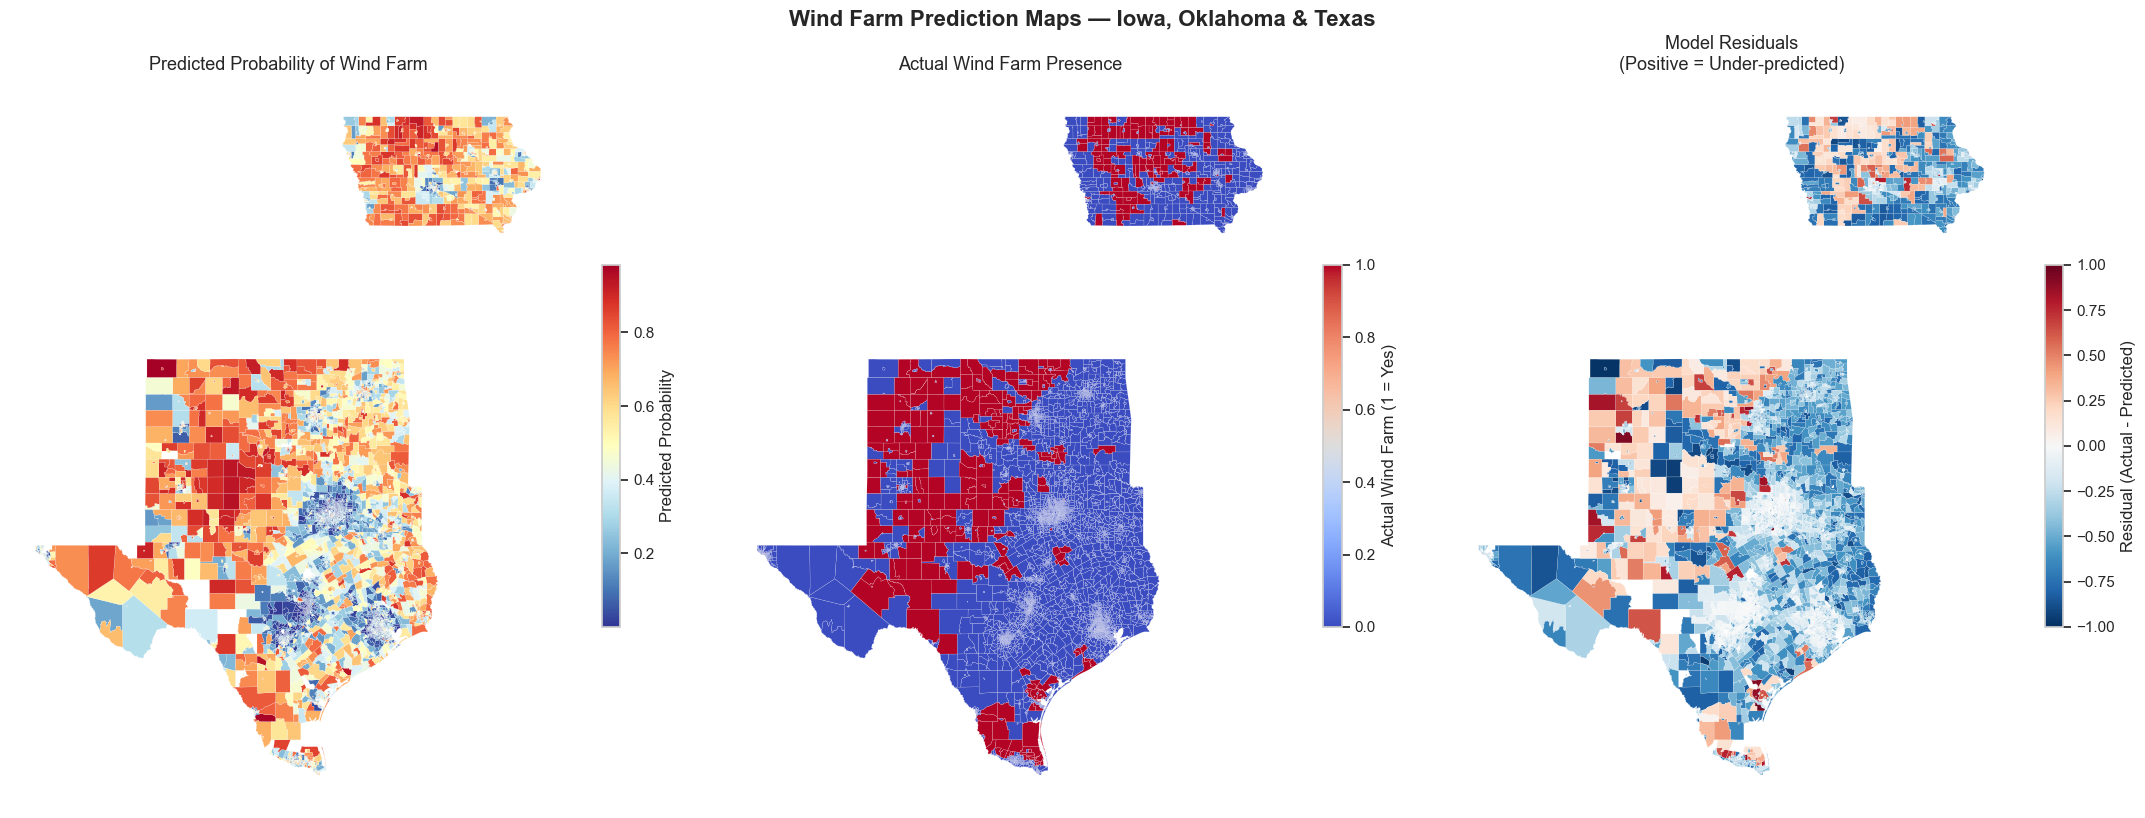


Predictions and residuals saved to: data/processed/tracts_with_predictions2.parquet


In [2]:
# ============================================================
# ROBUST PATH FIX
# ============================================================
import os
from pathlib import Path

try:
    project_root = Path(__file__).parent.parent
except NameError:
    cwd = Path(os.getcwd())
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

os.chdir(project_root)
print(f"Working directory set to: {os.getcwd()}")
# ============================================================


import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

sns.set_theme(style="whitegrid")

file_path = "data/processed/tracts_acs_wind_2024_expanded.parquet"

print("=" * 70)
print("Mapping Predicted Probabilities + Residuals")
print("=" * 70)

# ============================================================
# 1. LOAD DATA + PREPARE FEATURES
# ============================================================

gdf = gpd.read_parquet(file_path)

# Re-create engineered features
gdf["pct_recent_housing"] = gdf["housing_built_2010_or_later"] / (gdf["total_housing_units"] + 1)
gdf["housing_density"] = gdf["total_housing_units"] / (gdf["total_population"] + 1)
gdf["income_vs_home_value"] = gdf["median_household_income"] / (gdf["median_home_value"] + 1)

feature_cols = [
    "total_population",
    "total_housing_units",
    "median_household_income",
    "median_home_value",
    "housing_built_2010_or_later",
    "housing_built_before_2000",
    "pct_recent_housing",
    "housing_density",
    "income_vs_home_value"
]

df_model = gdf[feature_cols + ["has_wind_farm"]].dropna().copy()
X = df_model[feature_cols]

# ============================================================
# 2. TRAIN MODEL & GENERATE PREDICTIONS
# ============================================================

model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X, df_model["has_wind_farm"])

df_model["predicted_prob"] = model.predict_proba(X)[:, 1]

# Calculate residuals (Actual - Predicted)
df_model["residual"] = df_model["has_wind_farm"] - df_model["predicted_prob"]

# Merge back to full GeoDataFrame
gdf = gdf.merge(
    df_model[["predicted_prob", "residual"]], 
    left_index=True, 
    right_index=True, 
    how="left"
)

# ============================================================
# 3. CREATE THREE CHOROPLETH MAPS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(22, 8))

# Map 1: Predicted Probability
gdf.plot(
    column="predicted_prob",
    cmap="RdYlBu_r",
    linewidth=0.1,
    edgecolor="white",
    ax=axes[0],
    legend=True,
    legend_kwds={"label": "Predicted Probability", "shrink": 0.5}
)
axes[0].set_title("Predicted Probability of Wind Farm", fontsize=13, pad=10)
axes[0].axis("off")

# Map 2: Actual Wind Farm Presence
gdf.plot(
    column="has_wind_farm",
    cmap="coolwarm",
    linewidth=0.1,
    edgecolor="white",
    ax=axes[1],
    legend=True,
    legend_kwds={"label": "Actual Wind Farm (1 = Yes)", "shrink": 0.5}
)
axes[1].set_title("Actual Wind Farm Presence", fontsize=13, pad=10)
axes[1].axis("off")

# Map 3: Residuals (Actual - Predicted)
gdf.plot(
    column="residual",
    cmap="RdBu_r",
    linewidth=0.1,
    edgecolor="white",
    ax=axes[2],
    legend=True,
    legend_kwds={"label": "Residual (Actual - Predicted)", "shrink": 0.5},
    vmin=-1, vmax=1   # Keep scale centered at 0
)
axes[2].set_title("Model Residuals\n(Positive = Under-predicted)", fontsize=13, pad=10)
axes[2].axis("off")

plt.suptitle("Wind Farm Prediction Maps — Iowa, Oklahoma & Texas", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 4. SAVE THE RESULTS (Recommended)
# ============================================================

output_path = "data/processed/tracts_with_predictions2.parquet"
gdf.to_parquet(output_path, index=False)
print(f"\nPredictions and residuals saved to: {output_path}")

print("=" * 70)